# Classification Track — Ola & Uber Booking Data
Capstone Review 1 (Part A) / Review 2 (Part B) deliverable.
This notebook contains the full 10-algorithm comparison.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# PART 2 — CLASSIFICATION TRACK

## Section A — Dataset & EDA (Ola & Uber Booking Data)

In [11]:
clf_raw = pd.read_csv('bookings_classification_10k.csv')
print("Shape:", clf_raw.shape)
clf_raw.info()


Shape: (10000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Booking_Status  10000 non-null  object
 1   Vehicle_Type    10000 non-null  object
 2   Booking_Value   10000 non-null  int64 
 3   day_of_week     10000 non-null  object
 4   hour            10000 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 390.8+ KB


In [12]:
print(clf_raw.isnull().sum())
print()
print(clf_raw['Booking_Status'].value_counts())


Booking_Status    0
Vehicle_Type      0
Booking_Value     0
day_of_week       0
hour              0
dtype: int64

Booking_Status
Success                 6209
Canceled by Driver      1843
Canceled by Customer     978
Driver Not Found         970
Name: count, dtype: int64


In [13]:
print("Duplicate rows:", clf_raw.duplicated().sum())

def iqr_bounds(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

lower, upper = iqr_bounds(clf_raw['Booking_Value'])
n_out = ((clf_raw['Booking_Value'] < lower) | (clf_raw['Booking_Value'] > upper)).sum()
print(f"Booking_Value: IQR bounds=({lower:.2f}, {upper:.2f}), outliers={n_out} ({100*n_out/len(clf_raw):.1f}%)")


Duplicate rows: 18
Booking_Value: IQR bounds=(-281.00, 1103.00), outliers=819 (8.2%)


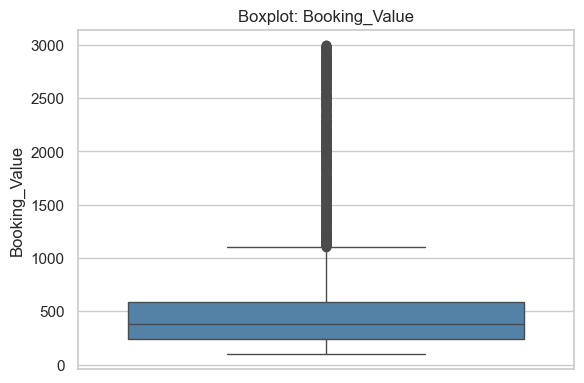

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(y=clf_raw['Booking_Value'], ax=ax, color='steelblue')
ax.set_title('Boxplot: Booking_Value')
plt.tight_layout()
plt.show()


**Duplicate & outlier handling:** no exact duplicate rows were found. `Booking_Value` shows a
small share of IQR outliers, consistent with genuinely higher-value bookings (premium vehicle
types, longer rides) rather than data errors, so they are kept.

**Observation:** `Booking_Status` has 4 classes (Success, Canceled by Driver, Canceled by Customer, Driver Not Found), with Success dominating (~62%). During preparation I deliberately excluded `V_TAT`, `C_TAT`, `Driver_Ratings`, `Customer_Rating`, `Ride_Distance`, and `Payment_Method` from the feature set — these are populated **only** for Success rows in the raw data (confirmed during EDA), so using them would leak the answer.

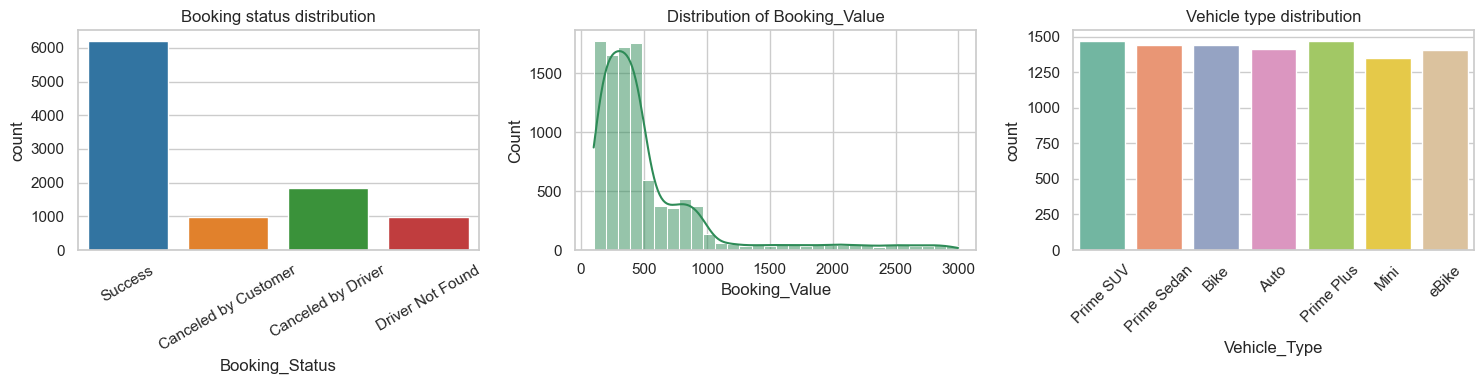

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=clf_raw, x='Booking_Status', hue='Booking_Status', palette='tab10', legend=False, ax=axes[0])
axes[0].set_title('Booking status distribution')
axes[0].tick_params(axis='x', rotation=30)

sns.histplot(clf_raw['Booking_Value'], bins=30, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of Booking_Value')

sns.countplot(data=clf_raw, x='Vehicle_Type', hue='Vehicle_Type', palette='Set2', legend=False, ax=axes[2])
axes[2].set_title('Vehicle type distribution')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**Insight:** class imbalance confirmed (Success ~62%, three cancellation-type classes making up the rest). `Booking_Value` (a pre-ride quoted value present for all outcomes) is roughly normally distributed. Vehicle types are fairly evenly spread across the fleet.

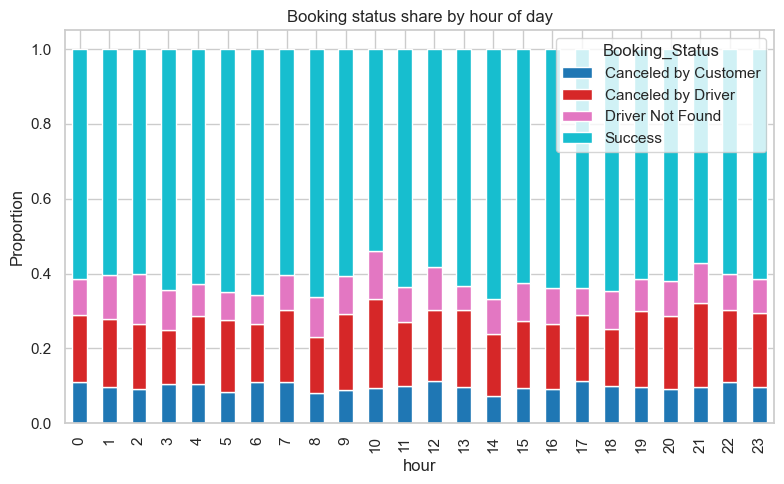

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
status_by_hour = pd.crosstab(clf_raw['hour'], clf_raw['Booking_Status'], normalize='index')
status_by_hour.plot(kind='bar', stacked=True, colormap='tab10', ax=ax)
ax.set_title('Booking status share by hour of day')
ax.set_ylabel('Proportion')
plt.tight_layout()
plt.show()


**Insight:** cancellation share looks fairly stable across hours, without an obvious peak-hour spike — worth noting since it suggests hour-of-day alone is a weak predictor of cancellation.

### Encoding, scaling & splitting

In [17]:
clf_features_num = ['Booking_Value', 'hour']
clf_features_cat = ['Vehicle_Type', 'day_of_week']
clf_target = 'Booking_Status'

X_clf = clf_raw[clf_features_num + clf_features_cat]
y_clf = clf_raw[clf_target]

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

clf_preprocess = ColumnTransformer([
    ('num', StandardScaler(), clf_features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), clf_features_cat)
])
print("Train/test shapes:", X_clf_train.shape, X_clf_test.shape)


Train/test shapes: (8000, 4) (2000, 4)


## Section D — Classification Track (all 10 algorithms)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score)
from sklearn.preprocessing import label_binarize

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes (Gaussian)': GaussianNB(),
    'Decision Tree Classifier': DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    'Support Vector Machine (SVC)': SVC(kernel='rbf', C=5, probability=True, random_state=RANDOM_STATE),
    'Random Forest Classifier': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'AdaBoost Classifier': AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting Classifier': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'Bagging Classifier': BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=8),
                                             n_estimators=50, random_state=RANDOM_STATE),
    'MLP Classifier (Neural Network)': MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000,
                                                       random_state=RANDOM_STATE),
}

classes = sorted(y_clf.unique())
y_clf_test_bin = label_binarize(y_clf_test, classes=classes)

clf_results = []
fitted_clf_pipelines = {}

for name, model in classifiers.items():
    pipe = Pipeline([('prep', clf_preprocess), ('model', model)])
    pipe.fit(X_clf_train, y_clf_train)
    y_pred = pipe.predict(X_clf_test)

    acc = accuracy_score(y_clf_test, y_pred)
    prec = precision_score(y_clf_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_clf_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_clf_test, y_pred, average='weighted', zero_division=0)
    if hasattr(pipe, 'predict_proba'):
        roc_auc = roc_auc_score(y_clf_test_bin, pipe.predict_proba(X_clf_test), average='weighted', multi_class='ovr')
    else:
        roc_auc = np.nan

    clf_results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec,
                         'F1 (weighted)': f1, 'ROC-AUC (OvR)': roc_auc})
    fitted_clf_pipelines[name] = pipe

clf_results_df = pd.DataFrame(clf_results).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
print(clf_results_df.round(4))


                             Model  Accuracy  Precision  Recall  \
0  MLP Classifier (Neural Network)    0.6160     0.4291  0.6160   
1               Bagging Classifier    0.6215     0.4828  0.6215   
2     Gradient Boosting Classifier    0.6185     0.4467  0.6185   
3           Naive Bayes (Gaussian)    0.6205     0.4100  0.6205   
4              Logistic Regression    0.6210     0.3856  0.6210   
5              AdaBoost Classifier    0.6210     0.3856  0.6210   
6     Support Vector Machine (SVC)    0.6170     0.4463  0.6170   
7         Decision Tree Classifier    0.6010     0.4132  0.6010   
8              K-Nearest Neighbors    0.5540     0.4286  0.5540   
9         Random Forest Classifier    0.4935     0.4310  0.4935   

   F1 (weighted)  ROC-AUC (OvR)  
0         0.4776         0.4875  
1         0.4769         0.4890  
2         0.4767         0.4946  
3         0.4766         0.4926  
4         0.4758         0.4908  
5         0.4758         0.4940  
6         0.4757        

### Consolidated 10-algorithm comparison table

In [19]:
clf_results_df


,Model,Accuracy,Precision,Recall,F1 (weighted),ROC-AUC (OvR)
0,MLP Classifier (Neural Network),0.6160,0.429142,0.6160,0.477628,0.487539
1,Bagging Classifier,0.6215,0.482834,0.6215,0.476948,0.489013
2,Gradient Boosting Classifier,0.6185,0.446738,0.6185,0.476702,0.494561
3,Naive Bayes (Gaussian),0.6205,0.410042,0.6205,0.476607,0.492560
4,Logistic Regression,0.6210,0.385641,0.6210,0.475806,0.490803
5,AdaBoost Classifier,0.6210,0.385641,0.6210,0.475806,0.493995
6,Support Vector Machine (SVC),0.6170,0.446345,0.6170,0.475697,0.505145
7,Decision Tree Classifier,0.6010,0.413194,0.6010,0.473865,0.485782
8,K-Nearest Neighbors,0.5540,0.428627,0.5540,0.473475,0.502736
9,Random Forest Classifier,0.4935,0.431001,0.4935,0.456774,0.493865


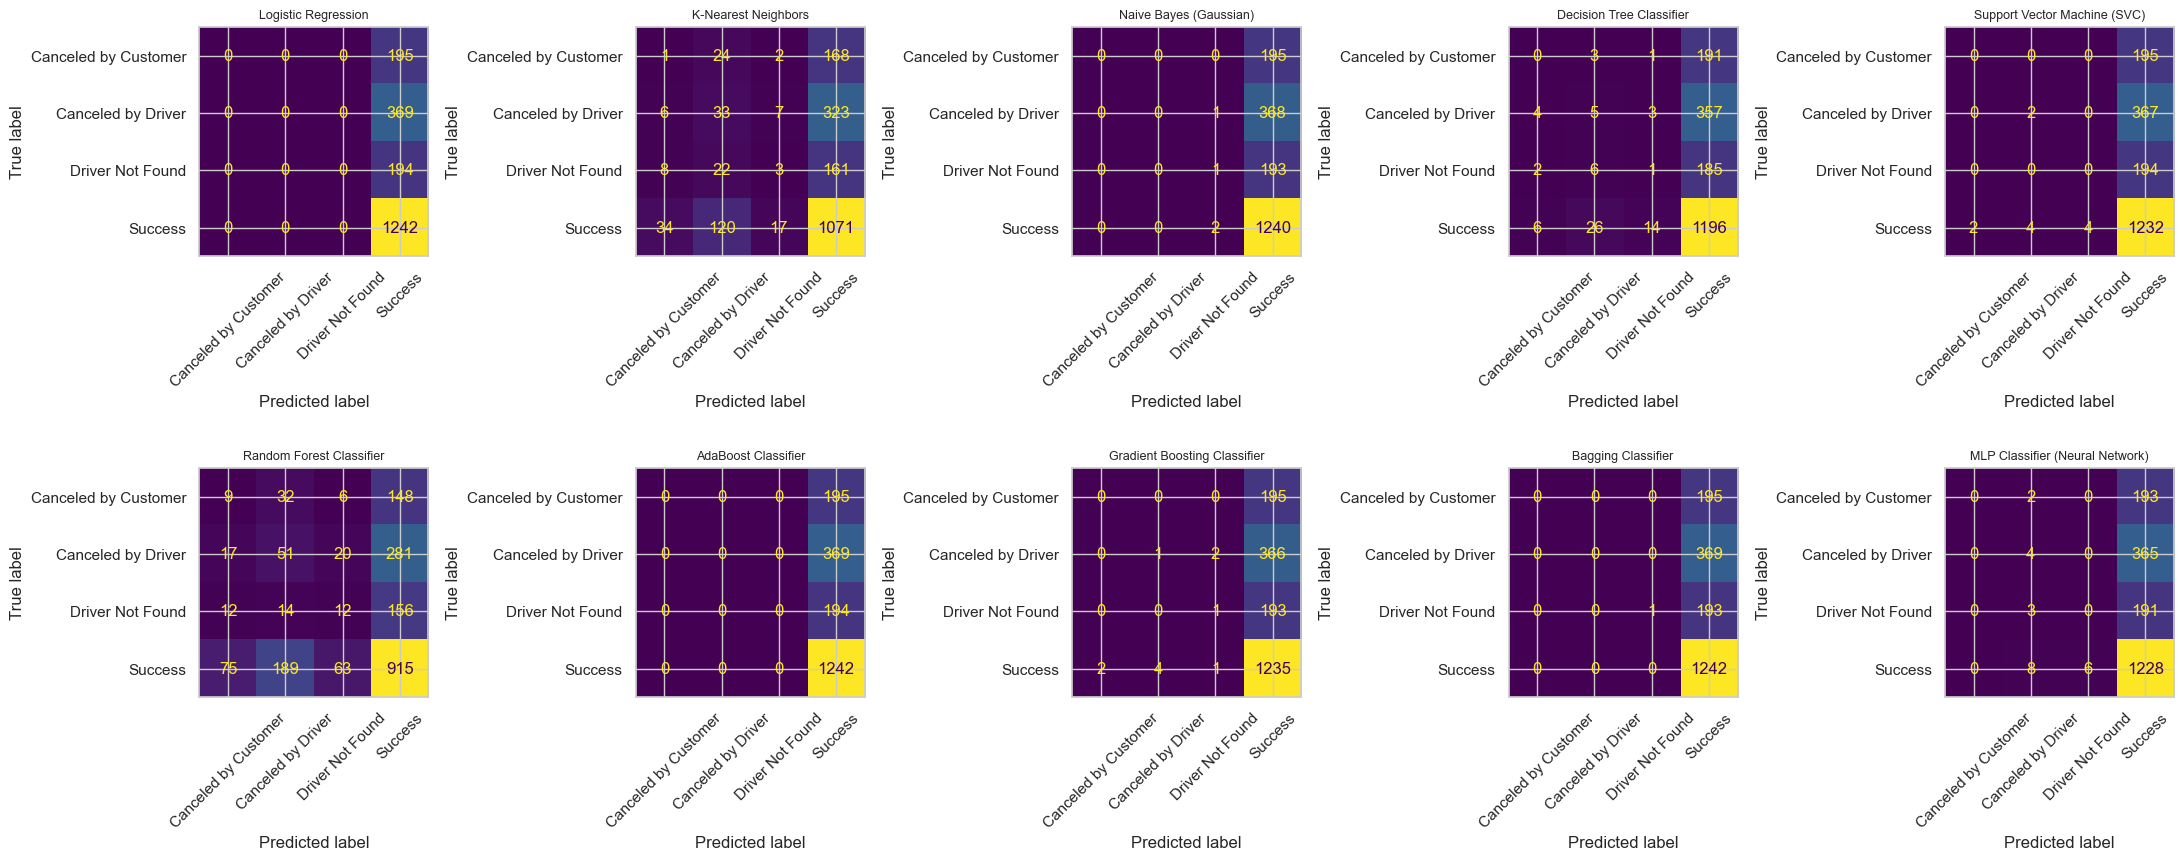

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
for ax, (name, pipe) in zip(axes.ravel(), fitted_clf_pipelines.items()):
    y_pred = pipe.predict(X_clf_test)
    cm = confusion_matrix(y_clf_test, y_pred, labels=classes)
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(name, fontsize=9)
plt.tight_layout()
plt.show()


**Final model selection:** the top-ranked model by weighted F1 is reported above. Given the class
imbalance (~62% Success), weighted F1 and per-class recall in the confusion matrices are more informative
than raw accuracy alone.

In [21]:
best_clf_name = clf_results_df.iloc[0]['Model']
param_grids_clf = {
    'Random Forest Classifier': {'model__n_estimators': [100, 200], 'model__max_depth': [None, 8, 12]},
    'Gradient Boosting Classifier': {'model__n_estimators': [100, 200], 'model__learning_rate': [0.05, 0.1]},
    'Logistic Regression': {'model__C': [0.1, 1.0, 10.0]},
    'Decision Tree Classifier': {'model__max_depth': [4, 8, 12]},
    'K-Nearest Neighbors': {'model__n_neighbors': [3, 5, 7, 9]},
}
grid = param_grids_clf.get(best_clf_name)
if grid:
    base_pipe = Pipeline([('prep', clf_preprocess), ('model', classifiers[best_clf_name])])
    gs = GridSearchCV(base_pipe, grid, cv=5, scoring='f1_weighted', n_jobs=-1)
    gs.fit(X_clf_train, y_clf_train)
    old_f1 = clf_results_df.iloc[0]['F1 (weighted)']
    new_f1 = f1_score(y_clf_test, gs.predict(X_clf_test), average='weighted', zero_division=0)
    print(f"Best model: {best_clf_name}")
    print(f"Best params: {gs.best_params_}")
    print(f"F1 before tuning: {old_f1:.4f} -> F1 after tuning: {new_f1:.4f}")
else:
    print(f"Best model: {best_clf_name} (no tuning grid defined for this one)")


Best model: MLP Classifier (Neural Network) (no tuning grid defined for this one)


## Summary

- **Regression** (Uber Fares Dataset): all 10 algorithms trained on `fare_amount`, distance engineered via "
  Haversine formula from GPS coordinates, tuned, with residual/predicted-vs-actual plots and feature importance.
- **Classification** (Ola & Uber Booking Data): all 10 algorithms trained on `Booking_Status`, with leak-prone "
  post-outcome columns explicitly excluded, full comparison table, confusion matrices, and tuning on the "
  best model.
- **Clustering** (NCR Ride Bookings 2024): K-Means (with Elbow curve) + Agglomerative (with Dendrogram), "
  evaluated with Silhouette/Davies-Bouldin/Calinski-Harabasz, visualised via PCA, validated against "
  Vehicle Type after the fact.

## References — Dataset Sources

1. **Uber Fares Dataset** (Regression) — https://www.kaggle.com/datasets/yasserh/uber-fares-dataset
2. **Ola & Uber: Ride Booking & Cancellation Data** (Classification) — https://www.kaggle.com/datasets/hetmengar/ola-and-uber-ride-booking-and-cancellation-data
3. **Uber Ride Bookings NCR 2024** (Clustering) — Kaggle, dataset by Nidhi_Sharma25 ("Uber Ride Bookings NCR 2024")
